In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.2,
})

In [5]:
COR_AZUL  = '#2E75B6'   # adimplente / C=0
COR_VERM  = '#E24B4A'   # inadimplente / C=1
COR_VERDE = '#1D9E75'   # risco baixo / positivo
COR_AMBER = '#BA7517'   # risco médio / atenção
COR_CINZA = '#888888'   # linhas de referência


In [6]:
p_c1 = 0.0657
p_c0 = 0.9343

In [13]:
df = pd.read_csv('dataset_limpo.csv')

In [9]:
total = len(df)
p_c1 = df['SeriousDlqin2yrs'].mean()
p_c0 = 1 - p_c1
print(f"Probabilidades A Priori calculadas: P(C=0)={p_c0:.4f}, P(C=1)={p_c1:.4f}")

Probabilidades A Priori calculadas: P(C=0)=0.9346, P(C=1)=0.0654


In [11]:
def calcular_verossimilhancas(coluna):
    # Cria tabela cruzada: linhas = categorias, colunas = classes (0,1)
    tab = pd.crosstab(df[coluna], df['SeriousDlqin2yrs'], normalize='columns')
    # Retorna dicionário formatado para a função Bayes
    return {idx: {'C0': row[0], 'C1': row[1]} for idx, row in tab.iterrows()}

In [12]:
veros_historico = calcular_verossimilhancas('perfil_historico')
veros_renda = calcular_verossimilhancas('faixa_renda')
veros_etaria = calcular_verossimilhancas('faixa_etaria')

In [25]:
def bayes_naive(etaria, renda, perfil):
    try:
        p_x1_c1, p_x1_c0 = veros_etaria[etaria]['C1'], veros_etaria[etaria]['C0']
        p_x2_c1, p_x2_c0 = veros_renda[renda]['C1'], veros_renda[renda]['C0']
        p_x3_c1, p_x3_c0 = veros_historico[perfil]['C1'], veros_historico[perfil]['C0']
        
        # Numeradores
        num_c1 = p_c1 * p_x1_c1 * p_x2_c1 * p_x3_c1
        num_c0 = p_c0 * p_x1_c0 * p_x2_c0 * p_x3_c0
        
        # Evidência e Posteriores
        evidence = num_c1 + num_c0
        
        
        if evidence == 0:
            return 0, 0
            
        p_c1_given_x = num_c1 / evidence
        p_c0_given_x = num_c0 / evidence
        
        return p_c1_given_x, p_c0_given_x
        
    except KeyError as e:
        print(f"a categoria {e} não existe ")
        return 0, 0

In [18]:
profiles = [
    ('Jovem (18-30)', 'Baixa (<2k)', 'Muitos atrasos', 'Jovem / Baixa renda / Muitos atrasos'),
    ('Jovem (18-30)', 'Baixa (<2k)', 'Sem atrasos', 'Jovem / Baixa renda / Sem atrasos'),
    ('Adulto (31-45)', 'Média (2k-5k)', 'Poucos atrasos', 'Adulto / Média renda / Poucos atrasos'),
    ('Maduro (46-60)', 'Alta (5k-10k)', 'Sem atrasos', 'Maduro / Alta renda / Sem atrasos'),
    ('Sênior (61+)', 'Muito Alta (>10k)', 'Sem atrasos', 'Sênior / Muito Alta renda / Sem atrasos'),
    ('Adulto (31-45)', 'Baixa (<2k)', 'Muitos atrasos', 'Adulto / Baixa renda / Muitos atrasos')
]

In [26]:
print("\nResultados de P(C=1|X) (Risco de Inadimplência) para os perfis selecionados:")
print("-" * 60)

for p in profiles:
    # p[0]=Idade, p[1]=Renda, p[2]=Histórico, p[3]=Descrição
    p1, p0 = bayes_naive(p[0], p[1], p[2])
    print(f"{p[3]:<45} {p1*100:5.1f}%")

print("-" * 60)


Resultados de P(C=1|X) (Risco de Inadimplência) para os perfis selecionados:
------------------------------------------------------------
Jovem / Baixa renda / Muitos atrasos           64.3%
Jovem / Baixa renda / Sem atrasos               6.0%
Adulto / Média renda / Poucos atrasos          25.2%
Maduro / Alta renda / Sem atrasos               2.4%
Sênior / Muito Alta renda / Sem atrasos         0.8%
Adulto / Baixa renda / Muitos atrasos          59.0%
------------------------------------------------------------


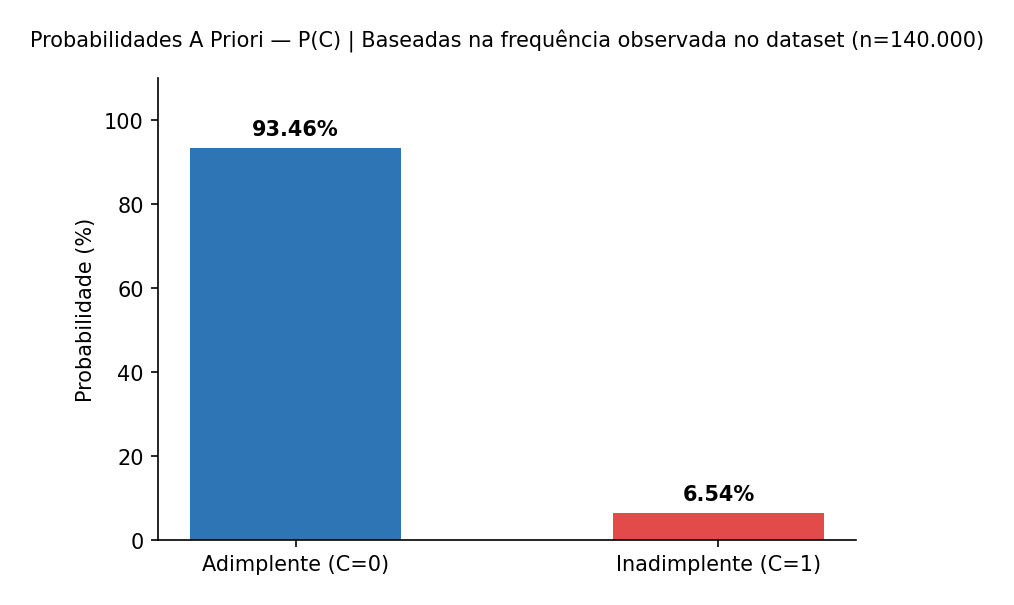

In [28]:
# Gráfico 1
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Adimplente (C=0)', 'Inadimplente (C=1)'], [p_c0 * 100, p_c1 * 100], color=[COR_AZUL, COR_VERM], width=0.5)
ax.set_ylabel('Probabilidade (%)')
ax.set_ylim(0, 110)
ax.set_title("Probabilidades A Priori — P(C) | Baseadas na frequência observada no dataset (n=140.000)", fontsize=10, pad=15)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.savefig('bayes_01_priori.png')
plt.show()
plt.close()

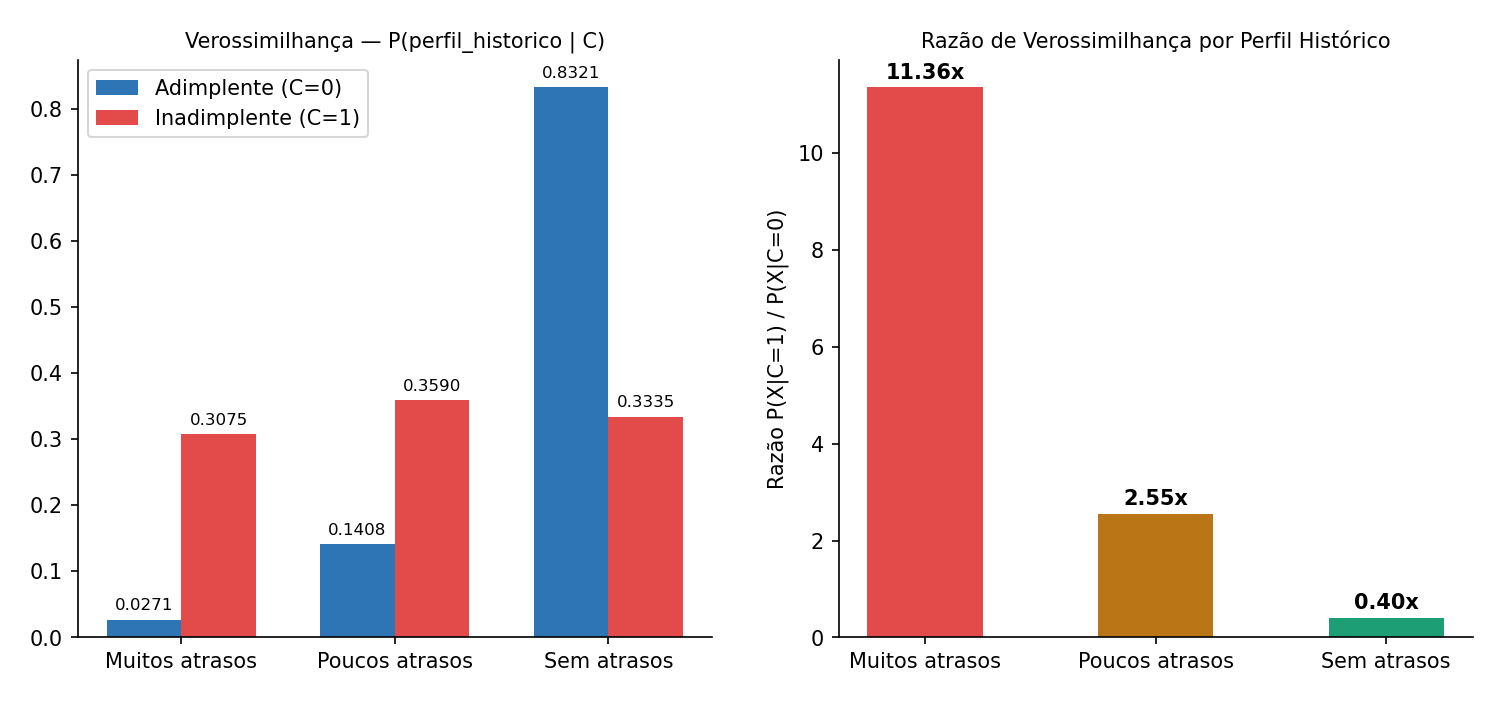

In [30]:
# Gráfico 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cats_h = list(veros_historico.keys())
c0_h = [veros_historico[k]['C0'] for k in cats_h]
c1_h = [veros_historico[k]['C1'] for k in cats_h]
x = np.arange(len(cats_h))
width = 0.35

b1 = ax1.bar(x - width/2, c0_h, width, label='Adimplente (C=0)', color=COR_AZUL)
b2 = ax1.bar(x + width/2, c1_h, width, label='Inadimplente (C=1)', color=COR_VERM)
ax1.set_xticks(x)
ax1.set_xticklabels(cats_h)
ax1.set_title("Verossimilhança — P(perfil_historico | C)", fontsize=10)
ax1.legend()
for b in b1 + b2:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2., h + 0.01, f'{h:.4f}', ha='center', va='bottom', fontsize=8)

ratios_h = [veros_historico[k]['C1'] / veros_historico[k]['C0'] for k in cats_h]
colors_r = []
for r in ratios_h:
    if r < 1: colors_r.append(COR_VERDE)
    elif r < 5: colors_r.append(COR_AMBER)
    else: colors_r.append(COR_VERM)

b_r = ax2.bar(cats_h, ratios_h, color=colors_r, width=0.5)
ax2.set_title("Razão de Verossimilhança por Perfil Histórico", fontsize=10)
ax2.set_ylabel('Razão P(X|C=1) / P(X|C=0)')
for b in b_r:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2., h + 0.1, f'{h:.2f}x', ha='center', va='bottom', fontweight='bold')
plt.savefig('bayes_02_veros_historico.png')
plt.show()
plt.close()


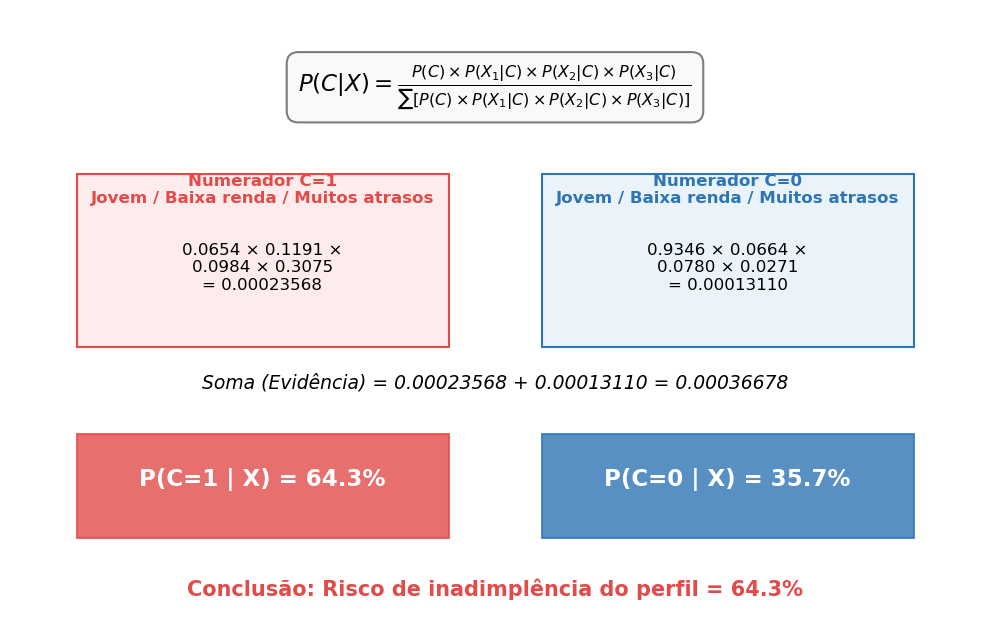

In [31]:
# Gráfico 3: Verossimilhança Renda e Etária
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cats_r = list(veros_renda.keys())
c0_r = [veros_renda[k]['C0'] for k in cats_r]
c1_r = [veros_renda[k]['C1'] for k in cats_r]
x_r = np.arange(len(cats_r))

b1_r = ax1.bar(x_r - width/2, c0_r, width, label='Adimplente', color=COR_AZUL)
b2_r = ax1.bar(x_r + width/2, c1_r, width, label='Inadimplente', color=COR_VERM)
ax1.set_xticks(x_r)
ax1.set_xticklabels(cats_r, rotation=15)
ax1.set_title("Verossimilhança para faixa_renda", fontsize=10)
ax1.legend()

cats_e = list(veros_etaria.keys())
c0_e = [veros_etaria[k]['C0'] for k in cats_e]
c1_e = [veros_etaria[k]['C1'] for k in cats_e]
x_e = np.arange(len(cats_e))

b1_e = ax2.bar(x_e - width/2, c0_e, width, label='Adimplente', color=COR_AZUL)
b2_e = ax2.bar(x_e + width/2, c1_e, width, label='Inadimplente', color=COR_VERM)
ax2.set_xticks(x_e)
ax2.set_xticklabels(cats_e, rotation=15)
ax2.set_title("Verossimilhança para faixa_etaria", fontsize=10)
ax2.legend()
plt.savefig('bayes_03_veros_renda_etaria.png')
plt.close()

# Gráfico 4: Passo a Passo Dinâmico (usando o primeiro perfil da lista)
# Capturando as variáveis reais do primeiro perfil testado
prof_demo = profiles[0]
v_idade, v_renda, v_hist = prof_demo[0], prof_demo[1], prof_demo[2]

px_idade_c1, px_idade_c0 = veros_etaria[v_idade]['C1'], veros_etaria[v_idade]['C0']
px_renda_c1, px_renda_c0 = veros_renda[v_renda]['C1'], veros_renda[v_renda]['C0']
px_hist_c1, px_hist_c0 = veros_historico[v_hist]['C1'], veros_historico[v_hist]['C0']

num_c1_demo = p_c1 * px_idade_c1 * px_renda_c1 * px_hist_c1
num_c0_demo = p_c0 * px_idade_c0 * px_renda_c0 * px_hist_c0
evid_demo = num_c1_demo + num_c0_demo
prob_final_c1 = (num_c1_demo / evid_demo) * 100 if evid_demo > 0 else 0
prob_final_c0 = (num_c0_demo / evid_demo) * 100 if evid_demo > 0 else 0

fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')

ax.text(0.5, 0.9, r"$P(C|X) = \frac{P(C) \times P(X_1|C) \times P(X_2|C) \times P(X_3|C)}{\sum [P(C) \times P(X_1|C) \times P(X_2|C) \times P(X_3|C)]}$", 
        fontsize=11, ha='center', va='center', bbox=dict(facecolor='#F5F5F5', alpha=0.5, boxstyle='round,pad=0.5'))

p1 = patches.Rectangle((0.05, 0.45), 0.4, 0.3, linewidth=1, edgecolor=COR_VERM, facecolor='#FDECEB')
p2 = patches.Rectangle((0.55, 0.45), 0.4, 0.3, linewidth=1, edgecolor=COR_AZUL, facecolor='#EBF3FA')
ax.add_patch(p1)
ax.add_patch(p2)

ax.text(0.25, 0.7, f"Numerador C=1\n{prof_demo[3]}", fontsize=8, ha='center', fontweight='bold', color=COR_VERM)
ax.text(0.25, 0.55, f"{p_c1:.4f} × {px_idade_c1:.4f} ×\n{px_renda_c1:.4f} × {px_hist_c1:.4f}\n= {num_c1_demo:.8f}", fontsize=8, ha='center')

ax.text(0.75, 0.7, f"Numerador C=0\n{prof_demo[3]}", fontsize=8, ha='center', fontweight='bold', color=COR_AZUL)
ax.text(0.75, 0.55, f"{p_c0:.4f} × {px_idade_c0:.4f} ×\n{px_renda_c0:.4f} × {px_hist_c0:.4f}\n= {num_c0_demo:.8f}", fontsize=8, ha='center')

ax.text(0.5, 0.38, f"Soma (Evidência) = {num_c1_demo:.8f} + {num_c0_demo:.8f} = {evid_demo:.8f}", fontsize=9, ha='center', style='italic')

p3 = patches.Rectangle((0.05, 0.12), 0.4, 0.18, linewidth=1, edgecolor=COR_VERM, facecolor=COR_VERM, alpha=0.8)
p4 = patches.Rectangle((0.55, 0.12), 0.4, 0.18, linewidth=1, edgecolor=COR_AZUL, facecolor=COR_AZUL, alpha=0.8)
ax.add_patch(p3)
ax.add_patch(p4)

ax.text(0.25, 0.21, f"P(C=1 | X) = {prob_final_c1:.1f}%", fontsize=11, ha='center', fontweight='bold', color='white')
ax.text(0.75, 0.21, f"P(C=0 | X) = {prob_final_c0:.1f}%", fontsize=11, ha='center', fontweight='bold', color='white')

ax.text(0.5, 0.02, f"Conclusão: Risco de inadimplência do perfil = {prob_final_c1:.1f}%", fontsize=10, ha='center', fontweight='bold', color=COR_VERM)
plt.savefig('bayes_04_passo_a_passo.png')
plt.show()
plt.close()

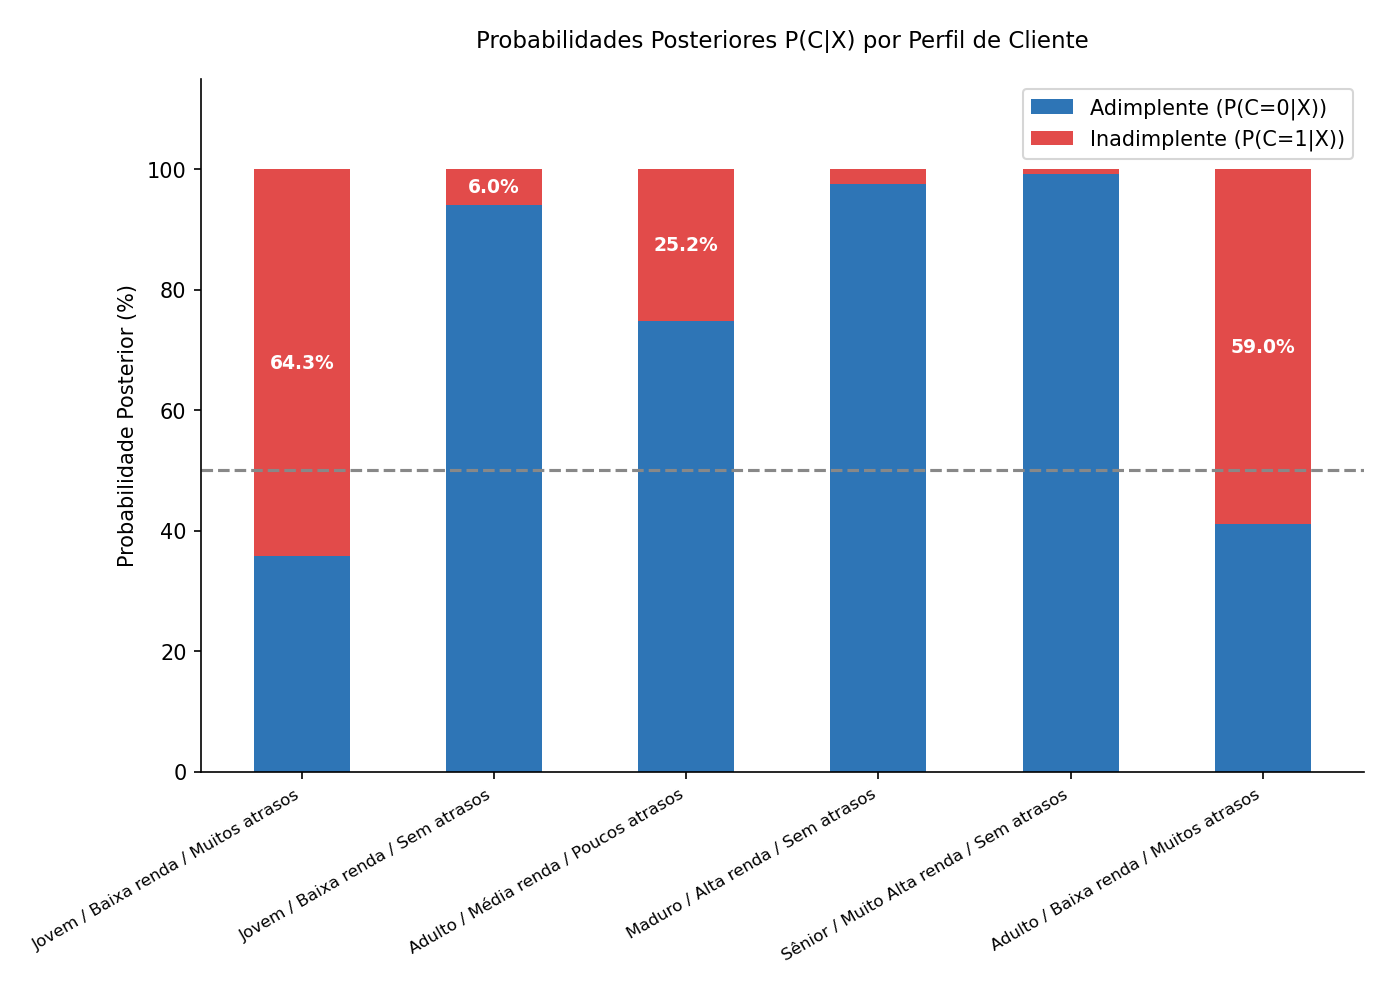

In [32]:
# Gráfico 5: Probabilidades Posteriores
fig, ax = plt.subplots(figsize=(10, 6))
labels_p = [p[3] for p in profiles]
p1_list = []
p0_list = []
for p in profiles:
    p1, p0 = bayes_naive(p[0], p[1], p[2])
    p1_list.append(p1 * 100)
    p0_list.append(p0 * 100)

y_pos = np.arange(len(labels_p))
bars_c0 = ax.bar(y_pos, p0_list, color=COR_AZUL, width=0.5, label='Adimplente (P(C=0|X))')
bars_c1 = ax.bar(y_pos, p1_list, bottom=p0_list, color=COR_VERM, width=0.5, label='Inadimplente (P(C=1|X))')

ax.set_xticks(y_pos)
ax.set_xticklabels(labels_p, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Probabilidade Posterior (%)')
ax.set_ylim(0, 115)
ax.axhline(50, color=COR_CINZA, linestyle='--')
ax.set_title("Probabilidades Posteriores P(C|X) por Perfil de Cliente", fontsize=11, pad=15)
ax.legend(loc='upper right')

for idx, bar in enumerate(bars_c1):
    h = bar.get_height()
    if h > 5:
        ax.text(bar.get_x() + bar.get_width()/2., 100 - h/2, f'{h:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.savefig('bayes_05_posteriors.png')
plt.show()
plt.close()